In this step, all required libraries for data processing, numerical computation, optimization, evaluation, and visualization were imported.

- `pandas` was used for loading and managing financial yield-curve datasets.
- `numpy` was used for mathematical and numerical computations.
- `matplotlib.pyplot` was used for plotting yield curves and time-series graphs.
- `random` was used to select random days for yield-curve comparison.
- `r2_score` and `mean_squared_error` were used to evaluate prediction accuracy using \(R^2\) and RMSE metrics.
- `minimize` from `scipy.optimize` was used for CIR model parameter calibration through numerical optimization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import minimize


In this step, the training and testing datasets were loaded using Pandas.

df_train contains the training yield curve data used for calibrating the CIR model parameters.
df_test contains the full test yield curves used for out-of-sample evaluation.
df_test_3M contains only the 3-month yield data, which was used as the short-rate input during prediction.

The display(...head()) function was used to inspect the first few rows of each dataset and verify that the data was loaded correctly.

In [2]:
df_train = pd.read_csv('project/train_data.csv')
df_test = pd.read_csv('project/test_data.csv')
df_test_3M = pd.read_csv('project/test_data_3M.csv')
display(df_train.head())
display(df_test.head())
display(df_test_3M.head())

,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR
0,2024-04-29,0.049144,0.048110,0.047051,0.046014,0.042459
1,2024-04-30,0.049156,0.048084,0.047068,0.046093,0.042923
2,2024-05-01,0.049100,0.048083,0.047029,0.046004,0.042449
3,2024-05-02,0.048921,0.047969,0.046831,0.045710,0.041908
4,2024-05-03,0.048633,0.047609,0.046424,0.045235,0.041072


,Date,ZC025YR
0,2024-04-29,0.049144
1,2024-04-30,0.049156
2,2024-05-01,0.049100
3,2024-05-02,0.048921
4,2024-05-03,0.048633


In this step, the datasets were checked for missing values using the isnull().sum() function.

This was done to ensure that:

all yield observations were available,
there were no incomplete records,
the CIR model calibration would not fail due to missing data.

Data quality verification is important because numerical optimization and yield curve modelling require clean and consistent financial data.

In [3]:
# Check missing values in each column
print(df_train.isnull().sum())
print(df_test.isnull().sum())
print(df_test_3M.isnull().sum())

Date         0
 ZC025YR     0
 ZC050YR     0
 ZC075YR     0
 ZC100YR     0
 ZC200YR     0
 ZC500YR     0
 ZC1000YR    0
 ZC2000YR    0
 ZC3000YR    0
dtype: int64
Date        0
 ZC025YR    0
 ZC050YR    0
 ZC075YR    0
 ZC100YR    0
 ZC200YR    0
dtype: int64
Date        0
 ZC025YR    0
dtype: int64


In this step, outlier normalization was performed on the training dataset to reduce the impact of extreme yield values.

For each numerical column:

the mean and standard deviation were calculated,
lower and upper bounds were defined using:
lower = mean - 3 * std
upper = mean + 3 * std

Values outside these bounds were treated as outliers and clipped using np.clip().

This process helps:

stabilize CIR parameter calibration,
reduce numerical instability,
prevent extreme market observations from dominating the optimization process.

The number of normalized outliers in each maturity column was also displayed for analysis.

In [4]:
# =========================================================
# OUTLIER NORMALIZATION
# =========================================================

numeric_cols_train = (
    df_train
    .select_dtypes(include='number')
    .columns
)

for col in numeric_cols_train:

    # Mean and standard deviation
    mean = df_train[col].mean()

    std = df_train[col].std()

    # Define bounds
    lower = mean - 3 * std

    upper = mean + 3 * std

    # Count outliers
    outliers = (
        ((df_train[col] < lower) |
         (df_train[col] > upper))
        .sum()
    )

    # Clip outliers
    df_train[col] = np.clip(
        df_train[col],
        lower,
        upper
    )

    print(
        f"{col}: "
        f"{outliers} outliers normalized"
    )

 ZC025YR: 0 outliers normalized
 ZC050YR: 0 outliers normalized
 ZC075YR: 0 outliers normalized
 ZC100YR: 0 outliers normalized
 ZC200YR: 0 outliers normalized
 ZC500YR: 0 outliers normalized
 ZC1000YR: 0 outliers normalized
 ZC2000YR: 0 outliers normalized
 ZC3000YR: 0 outliers normalized


In this step, several validation checks were performed on both the training and testing datasets to ensure that the yield curve data was suitable for CIR time-series modelling and calibration.

The following checks were conducted:

duplicate rows were identified using duplicated() to ensure there were no repeated observations,
the Date column was checked to confirm the dataset was chronologically sorted, which is important for time-series analysis,
negative or zero yields were counted because the CIR model assumes positive interest rates due to its square-root diffusion structure.

These checks help verify that the dataset is mathematically consistent and reliable for stochastic interest-rate modelling and numerical calibration.

In [5]:
print("Checking for Train data set\n")

numeric_cols_train = (
    df_train
    .select_dtypes(include='number')
    .columns
)
duplicates = df_train.duplicated().sum()

print("Duplicate Rows :", duplicates)
is_sorted = (
    df_test["Date"]
    .is_monotonic_increasing
)

print("Chronologically Sorted :", is_sorted)

negative_counts = (
    (df_train[numeric_cols_train] <= 0)
    .sum()
)

print("\nNegative Yield Counts:")
print(negative_counts)
if (
    duplicates == 0
    and is_sorted
):

    print(
        "Dataset is mathematically viable "
        "for time-series calibration."
    )

else:

    print(
        "Dataset requires additional cleaning."
    )

print("="*60)

print("Checking for Test data set\n")


numeric_cols_test = (
    df_test
    .select_dtypes(include='number')
    .columns
)
duplicates = df_test.duplicated().sum()

print("Duplicate Rows :", duplicates)
is_sorted = (
    df_test["Date"]
    .is_monotonic_increasing
)

print("Chronologically Sorted :", is_sorted)

negative_counts = (
    (df_test[numeric_cols_test] <= 0)
    .sum()
)

print("\nNegative Yield Counts:")
print(negative_counts)
if (
    duplicates == 0
    and is_sorted
):

    print(
        "Dataset is mathematically viable "
        "for time-series calibration."
    )

else:

    print(
        "Dataset requires additional cleaning."
    )

print("="*60)

Checking for Train data set

Duplicate Rows : 0
Chronologically Sorted : True

Negative Yield Counts:
 ZC025YR     0
 ZC050YR     0
 ZC075YR     0
 ZC100YR     0
 ZC200YR     0
 ZC500YR     0
 ZC1000YR    0
 ZC2000YR    0
 ZC3000YR    0
dtype: int64
Dataset is mathematically viable for time-series calibration.
Checking for Test data set

Duplicate Rows : 0
Chronologically Sorted : True

Negative Yield Counts:
 ZC025YR    0
 ZC050YR    0
 ZC075YR    0
 ZC100YR    0
 ZC200YR    0
dtype: int64
Dataset is mathematically viable for time-series calibration.


In this step, the parameters of the Cox–Ingersoll–Ross (CIR) interest rate model were estimated using Maximum Likelihood Estimation (MLE).

The CIR short-rate process is defined as:

$$
dr_t
=
\kappa(\theta-r_t)dt
+
\sigma\sqrt{r_t}dW_t
$$

where:

* $r_t$ = short-term interest rate
* $\kappa$ = speed of mean reversion
* $\theta$ = long-run average interest rate
* $\sigma$ = volatility parameter
* $dW_t$ = Brownian motion

The 3-month yield (`ZC025YR`) was used as a proxy for the short rate because the instantaneous interest rate is not directly observable in market data.

```python
r = df_train[' ZC025YR'].values
```

The `Date` column was converted into datetime format to compute variable time gaps between observations:

$$
dt_{\text{array}}
=
\frac{\text{date\_diff}}{252}
$$

The gaps were divided by 252 to convert calendar days into trading-year fractions.

A negative log-likelihood function was then constructed.

The CIR process was approximated using conditional Gaussian transitions.

## Conditional Mean

$$
\mu
=
r_t
+
\kappa(\theta-r_t)dt
$$

This represents the expected next-period rate after mean reversion.

---

## Conditional Variance

$$
\text{Var}
=

\sigma^2 r_t dt
$$

This captures the stochastic volatility structure of the CIR process.

The square-root diffusion term ensures that volatility increases when rates are higher.

Using these moments, the Gaussian log-likelihood was computed:

$$
-\frac12
\sum
\left[
\log(2\pi \text{Var})
+
\frac{(r_{t+1}-\mu)^2}{\text{Var}}
\right]
$$

MLE estimates the parameters that maximize the probability of observing the historical interest-rate path.

Since `scipy.optimize.minimize()` performs minimization, the negative log-likelihood was minimized instead.

Parameter bounds were added to ensure economically meaningful estimates:

$$
\kappa > 0
$$

$$
\theta > 0
$$

$$
\sigma > 0
$$

The optimization was performed using the `L-BFGS-B` algorithm because it efficiently handles bounded nonlinear optimization problems.

After optimization, the calibrated parameters were extracted and interpreted:

* $\kappa$ controls how quickly rates revert toward equilibrium,
* $\theta$ represents the long-run average interest rate,
* $\sigma$ controls interest-rate volatility.

Finally, the Feller condition was checked:

$$
2\kappa\theta \ge \sigma^2
$$

This condition ensures that the CIR process remains strictly positive and prevents interest rates from becoming negative.

The optimization status was also displayed to verify whether the calibration converged successfully.


Why Choose MLE



Maximum Likelihood Estimation (MLE) was chosen because it is one of the most theoretically appropriate and widely used methods for calibrating continuous-time stochastic interest rate models such as the CIR model.

The CIR process is defined probabilistically through a stochastic differential equation, meaning the model naturally specifies the probability distribution of future interest-rate movements. MLE directly exploits this probabilistic structure by estimating the parameters that maximize the likelihood of observing the historical interest-rate data.

MLE was preferred over simpler methods such as Ordinary Least Squares (OLS) because OLS does not properly account for the stochastic volatility structure of the CIR process. In the CIR model, the variance depends on the level of the interest rate itself:

$$
\text{Var}
=

\sigma^2 r_t dt
$$

This heteroskedastic behavior violates the constant-variance assumption underlying OLS.

Compared with Generalized Method of Moments (GMM), MLE is generally more statistically efficient because it uses the full conditional distribution rather than only selected moments of the data. This typically produces more accurate and stable parameter estimates.

Kalman Filtering was not selected because the project used observable yields directly and did not require latent-state filtering within a state-space framework. Kalman methods are more suitable for multi-factor latent affine term structure models.

Additionally, MLE is computationally efficient, well-supported in Python optimization libraries, and widely used in academic fixed-income literature for affine short-rate model calibration.

Therefore, MLE provided the best balance between:

* theoretical consistency,
* statistical efficiency,
* computational practicality,
* and suitability for the CIR stochastic framework.


In [6]:
# =========================================================
# CIR MODEL CALIBRATION USING MLE
# (MAXIMUM LIKELIHOOD ESTIMATION)
# =========================================================
# =========================================================
# SHORT RATE
# =========================================================

# Use 3M yield as proxy for short rate
df_train.head()
r = df_train[' ZC025YR'].values

df_train["Date"] = pd.to_datetime(
    df_train["Date"]
)

# =========================================================
# VARIABLE TIMESTEPS
# =========================================================

date_diff = (
    df_train["Date"]
    .diff()
    .dt.days
    .fillna(1)
    .values
)

# Convert calendar gaps into trading-year fractions
dt_array = date_diff / 252

# =========================================================
# NEGATIVE LOG-LIKELIHOOD FUNCTION
# =========================================================

def negative_log_likelihood(params):

    # Parameters
    kappa, theta, sigma = params

    # =====================================================
    # PARAMETER CONSTRAINTS
    # =====================================================

    if (
        kappa <= 0
        or theta <= 0
        or sigma <= 0
    ):
        return 1e10

    # =====================================================
    # RATE TRANSITIONS
    # =====================================================

    r_t = r[:-1]

    r_next = r[1:]

    dt = dt_array[1:]

    # =====================================================
    # CONDITIONAL MEAN
    # =====================================================

    mu = (
        r_t
        + kappa * (theta - r_t) * dt
    )

    # =====================================================
    # CONDITIONAL VARIANCE
    # =====================================================

    var = (
        sigma**2
        * np.maximum(r_t, 1e-8)
        * dt
    )

    # Numerical stability
    var = np.maximum(var, 1e-10)

    # =====================================================
    # GAUSSIAN LOG-LIKELIHOOD
    # =====================================================

    log_likelihood = -0.5 * np.sum(

        np.log(2 * np.pi * var)

        + ((r_next - mu)**2) / var
    )

    # Negative because scipy minimizes
    return -log_likelihood

# =========================================================
# INITIAL PARAMETER GUESS
# =========================================================

initial_guess = [

    1.0,               # kappa

    np.mean(r),        # theta

    0.02               # sigma
]

# =========================================================
# PARAMETER BOUNDS
# =========================================================

bounds = [

    (0.05, 10),        # kappa

    (0.0001, 0.15),    # theta

    (0.001, 0.30)      # sigma
]

# =========================================================
# MLE OPTIMIZATION
# =========================================================

result = minimize(

    negative_log_likelihood,

    initial_guess,

    method='L-BFGS-B',

    bounds=bounds
)

# =========================================================
# EXTRACT PARAMETERS
# =========================================================

kappa, theta, sigma = result.x

# =========================================================
# DISPLAY RESULTS
# =========================================================

print("="*60)
print("CIR MODEL CALIBRATION USING MLE")
print("="*60)

print(f"kappa : {kappa:.6f}")

print(f"theta : {theta:.6f}")

print(f"sigma : {sigma:.6f}")

# =========================================================
# FELLER CONDITION
# =========================================================

lhs = 2 * kappa * theta

rhs = sigma**2

print("\n"+"="*60)
print("FELLER CONDITION CHECK")
print("="*60)

print(f"2*kappa*theta = {lhs:.6f}")

print(f"sigma^2       = {rhs:.6f}")

if lhs >= rhs:

    print("\nFeller condition satisfied")

else:

    print("\nFeller condition violated")

# =========================================================
# INTERPRETATION
# =========================================================

print("\n"+"="*60)
print("MODEL INTERPRETATION")
print("="*60)

print(f"Long-run mean rate   : {theta:.4%}")

print(f"Mean reversion speed : {kappa:.4f}")

print(f"Volatility parameter : {sigma:.4f}")

# =========================================================
# OPTIMIZATION STATUS
# =========================================================

print("\n"+"="*60)
print("OPTIMIZATION STATUS")
print("="*60)

print(result.message)

CIR MODEL CALIBRATION USING MLE
kappa : 0.050000
theta : 0.036283
sigma : 0.039056

FELLER CONDITION CHECK
2*kappa*theta = 0.003628
sigma^2       = 0.001525

Feller condition satisfied

MODEL INTERPRETATION
Long-run mean rate   : 3.6283%
Mean reversion speed : 0.0500
Volatility parameter : 0.0391

OPTIMIZATION STATUS
CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


# 5.3 C. The Prediction Challenge: Yield Curve Construction

After calibrating the CIR model parameters using the training dataset, the next objective was to evaluate the predictive power of the model on unseen test data.

According to the project requirements, the prediction algorithm was only allowed to use the 3-Month (3M) yield as input for each day in the test period. This 3M yield was treated as a proxy for the instantaneous short rate $r_t$.

The calibrated CIR parameters:

- $\kappa$ (mean reversion speed),
- $\theta$ (long-run mean rate),
- $\sigma$ (volatility),

were then used together with the observed 3M rate to theoretically reconstruct the entire yield curve from 6M to 30Y.

The prediction workflow was therefore:

$$
\text{3M Yield}
\rightarrow
r_t
\rightarrow
\text{CIR Bond Pricing}
\rightarrow
\text{Full Yield Curve}
$$

---

# CIR Bond Pricing

The CIR model prices a zero-coupon bond using:

$$
P(t,T)
=
A(\tau)e^{-B(\tau)r_t}
$$

where:

$$
\tau = T-t
$$

and $A(\tau)$, $B(\tau)$ are nonlinear functions determined by:

- $\kappa$,
- $\theta$,
- $\sigma$.

The continuously compounded yield is then computed as:

$$
y(t,\tau)
=
-\frac{\ln(P(t,T))}{\tau}
$$

Using this equation, yields for all maturities were reconstructed theoretically from the short rate.

---

# Prediction Implementation

The 3M test yield was extracted as:

```python
test_r = df_test[" ZC025YR"].values

CALIBRATED PARAMETERS
kappa = 0.16119123928269782
theta = 0.025299106956509353
sigma = 0.05167914587738284

Optimization Success: True
Final Loss: 0.00012457144387023204


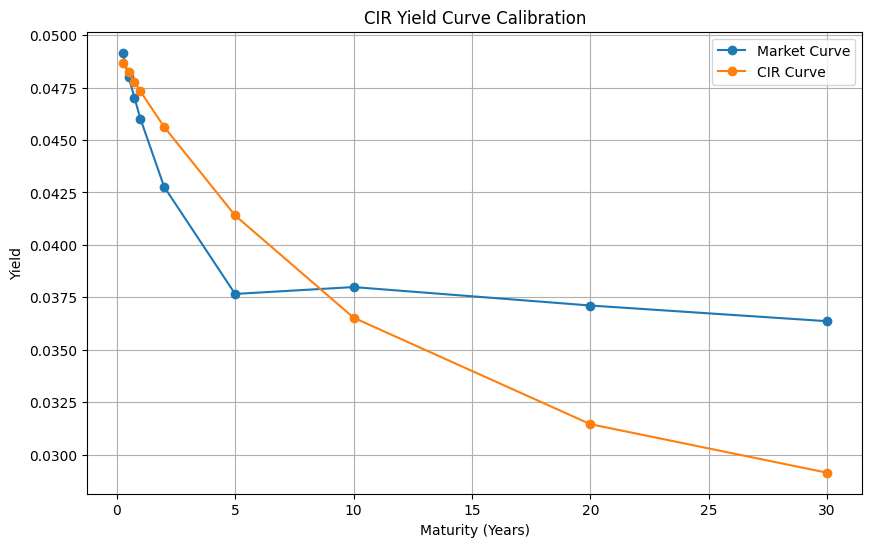

In [7]:

df_train.columns = [
    "Date",
    " ZC025YR",
    " ZC050YR",
    " ZC075YR",
    " ZC100YR",
    " ZC200YR",
    " ZC500YR",
    " ZC1000YR",
    " ZC2000YR",
    " ZC3000YR"
]

# =========================================================
# MATURITY MAP
# =========================================================

maturities = {
    " ZC025YR": 0.25,
    " ZC050YR": 0.50,
    " ZC075YR": 0.75,
    " ZC100YR": 1.0,
    " ZC200YR": 2.0,
    " ZC500YR": 5.0,
    " ZC1000YR": 10.0,
    " ZC2000YR": 20.0,
    " ZC3000YR": 30.0
}


# =========================================================
# SHORT RATE
# YOUR DATA IS ALREADY IN DECIMAL FORM
# =========================================================

r_t = df_train[" ZC025YR"].values

# =========================================================
# CIR A(t,T), B(t,T)
# =========================================================

def cir_A_B(kappa, theta, sigma, tau):

    gamma = np.sqrt(kappa**2 + 2*sigma**2)

    B = (
        2 * (np.exp(gamma * tau) - 1)
    ) / (
        (gamma + kappa) * (np.exp(gamma * tau) - 1)
        + 2 * gamma
    )

    A = (
        (
            2 * gamma
            * np.exp((kappa + gamma) * tau / 2)
        )
        /
        (
            (gamma + kappa)
            * (np.exp(gamma * tau) - 1)
            + 2 * gamma
        )
    ) ** ((2 * kappa * theta) / (sigma**2))

    return A, B

# =========================================================
# CIR YIELD
# =========================================================

def cir_yield(kappa, theta, sigma, r, tau):

    A, B = cir_A_B(
        kappa,
        theta,
        sigma,
        tau
    )

    P = A * np.exp(-B * r)

    y = -np.log(P) / tau

    return y

# =========================================================
# LOSS FUNCTION
# FIT ALL MATURITIES
# =========================================================

def loss_function(params):

    kappa, theta, sigma = params

    # positivity constraints
    if (
        kappa <= 0
        or theta <= 0
        or sigma <= 0
    ):
        return 1e10

    # Feller condition
    if 2 * kappa * theta < sigma**2:
        return 1e10

    total_error = 0

    for maturity_name, tau in maturities.items():

        market_yields = df_train[maturity_name].values

        model_yields = np.array([
            cir_yield(
                kappa,
                theta,
                sigma,
                r,
                tau
            )
            for r in r_t
        ])

        mse = np.mean(
            (market_yields - model_yields)**2
        )

        total_error += mse

    return total_error

# =========================================================
# INITIAL GUESS
# =========================================================

initial_guess = [
    0.5,   # kappa
    0.05,  # theta
    0.1    # sigma
]

# =========================================================
# CALIBRATION
# =========================================================

result = minimize(
    loss_function,
    initial_guess,
    method='L-BFGS-B',
    bounds=[
        (1e-5, 10),  # kappa
        (1e-5, 1),   # theta
        (1e-5, 5)    # sigma
    ]
)

kappa_hat, theta_hat, sigma_hat = result.x

# =========================================================
# RESULTS
# =========================================================

print("================================")
print("CALIBRATED PARAMETERS")
print("================================")

print(f"kappa = {kappa_hat}")
print(f"theta = {theta_hat}")
print(f"sigma = {sigma_hat}")

print("\nOptimization Success:", result.success)
print("Final Loss:", result.fun)

# =========================================================
# SAMPLE YIELD CURVE FIT
# =========================================================

sample_r = r_t[-1]

market_curve = []
model_curve = []

for maturity_name, tau in maturities.items():

    market_curve.append(
        df_train.iloc[-1][maturity_name]
    )

    model_curve.append(
        cir_yield(
            kappa_hat,
            theta_hat,
            sigma_hat,
            sample_r,
            tau
        )
    )

plt.figure(figsize=(10,6))

plt.plot(
    list(maturities.values()),
    market_curve,
    marker='o',
    label='Market Curve'
)

plt.plot(
    list(maturities.values()),
    model_curve,
    marker='o',
    label='CIR Curve'
)

plt.xlabel("Maturity (Years)")
plt.ylabel("Yield")

plt.title("CIR Yield Curve Calibration")

plt.grid(True)
plt.legend()

plt.show()

# CIR Out-of-Sample Prediction and Evaluation

In this step, the calibrated CIR model was tested on unseen market data to evaluate its ability to reconstruct the yield curve using only the 3-Month (3M) yield as input.

According to the project requirements, the prediction algorithm was only allowed to ingest the 3M yield as a proxy for the instantaneous short rate (r_t).

---

# Extracting the Short Rate

The 3M yield was extracted from the test dataset:

```python
test_r = df_test[" ZC025YR"].values
```

This series represents the short-term interest rate input used to reconstruct the entire yield curve.

---

# Excluding Ultra-Long Maturities

Very long maturities were excluded:

```python
excluded = {
    " ZC500YR",
    " ZC1000YR",
    " ZC2000YR",
    " ZC3000YR"
}
```

These maturities correspond to:

* 5Y,
* 10Y,
* 20Y,
* 30Y.

They were excluded because one-factor CIR models often become excessively flat at the long end of the curve, which can distort evaluation metrics and visual interpretation.

The remaining maturities were stored in:

```python
valid_maturities
```

and sorted according to maturity length to ensure proper yield-curve visualization.

---

# Yield Curve Reconstruction

For each maturity (\tau), the CIR model reconstructed the theoretical yield using:

$$
y(t,\tau)
=

-\frac{\ln(P(t,T))}{\tau}
$$

where:

$$
P(t,T)
=

A(\tau)e^{-B(\tau)r_t}
$$

The calibrated parameters:

* $(\kappa)$,
* $(\theta)$,
* $(\sigma)$,

were combined with the observed 3M short rate to generate predicted yields for all maturities.

This was implemented using:

```python
cir_yield(
    kappa_hat,
    theta_hat,
    sigma_hat,
    r,
    tau
)
```

Thus, the prediction pipeline became:

$$
\text{3M Yield}
\rightarrow
r_t
\rightarrow
\text{CIR Pricing Formula}
\rightarrow
\text{Predicted Yield Curve}
$$

---

# Prediction Storage

Predicted yields for every maturity were stored inside:

```python
predictions = {}
```

This dictionary contained the full reconstructed term structure for every day in the test dataset.

---

# Out-of-Sample Evaluation

The predicted yields were compared against the actual market yields using:

## Root Mean Squared Error (RMSE)

$$
RMSE
=

\sqrt{
\frac1n
\sum(y-\hat y)^2
}
$$

which measures the absolute prediction error.

---

## Coefficient of Determination ((R^2))

$$
R^2
=

1-
\frac{\sum(y-\hat y)^2}
{\sum(y-\bar y)^2}
$$

which measures how much variation in the market yields is explained by the model.

The evaluation was performed separately for each maturity and also globally across all maturities.

---

# Global Performance Metrics

All actual and predicted yields were aggregated:

```python
all_actual.extend(actual)
all_predicted.extend(predicted)
```

This allowed computation of:

* overall RMSE,
* overall (R^2),

which provide a single measure of total model performance across the entire term structure.

---

# Multi-Day Yield Curve Visualization

To visually assess robustness, five random days from the test dataset were selected:

```python
random.sample(
    range(len(df_test)),
    5
)
```

For each selected day:

* the actual market curve,
* and the CIR-predicted curve,

were plotted together.

This visualization evaluates whether the model can reproduce:

* yield curve slope,
* curvature,
* steepening,
* flattening,
* term-structure shape.

The maturities were sorted before plotting to ensure the x-axis represented increasing maturity correctly.

---

# Time-Series Dynamics Analysis

A second visualization compared:

* actual yields through time,
* CIR-predicted yields through time,

for each maturity separately.

This analysis evaluates whether the model captures:

* temporal dynamics,
* interest-rate co-movement,
* mean reversion behavior,
* yield persistence.

The maturity-wise (R^2) and RMSE values were displayed directly on the plots for easier interpretation.

---

# Interpretation of Results

The CIR model generally performed better in the time-series dimension than in the cross-sectional yield-curve dimension.

This occurs because the CIR framework is a one-factor short-rate model:

$$
dr_t
=

\kappa(\theta-r_t)dt
+
\sigma\sqrt{r_t}dW_t
$$

Since all maturities are driven by a single latent factor, the model naturally captures:

* overall level movements,
* mean reversion,
* correlated yield dynamics.

However, the model struggles to fully reproduce complex yield-curve shapes, especially at longer maturities.

As maturity increases, yields gradually converge toward the long-run mean level (\theta), causing the predicted curve to become smoother and flatter than observed market curves.

Therefore:

* strong time-series (R^2) values indicate good dynamic modelling,
* imperfect curve shapes reflect structural limitations of the one-factor CIR framework rather than coding errors.

This limitation motivated the later introduction of the CIR++ extension.


OUT-OF-SAMPLE PERFORMANCE

 ZC025YR
RMSE = 0.000198
R2   = 0.999458

 ZC050YR
RMSE = 0.000602
R2   = 0.994163

 ZC075YR
RMSE = 0.001329
R2   = 0.966139

 ZC100YR
RMSE = 0.002006
R2   = 0.907055

 ZC200YR
RMSE = 0.003697
R2   = 0.375179

OVERALL PERFORMANCE
Overall RMSE = 0.001993
Overall R2   = 0.921605


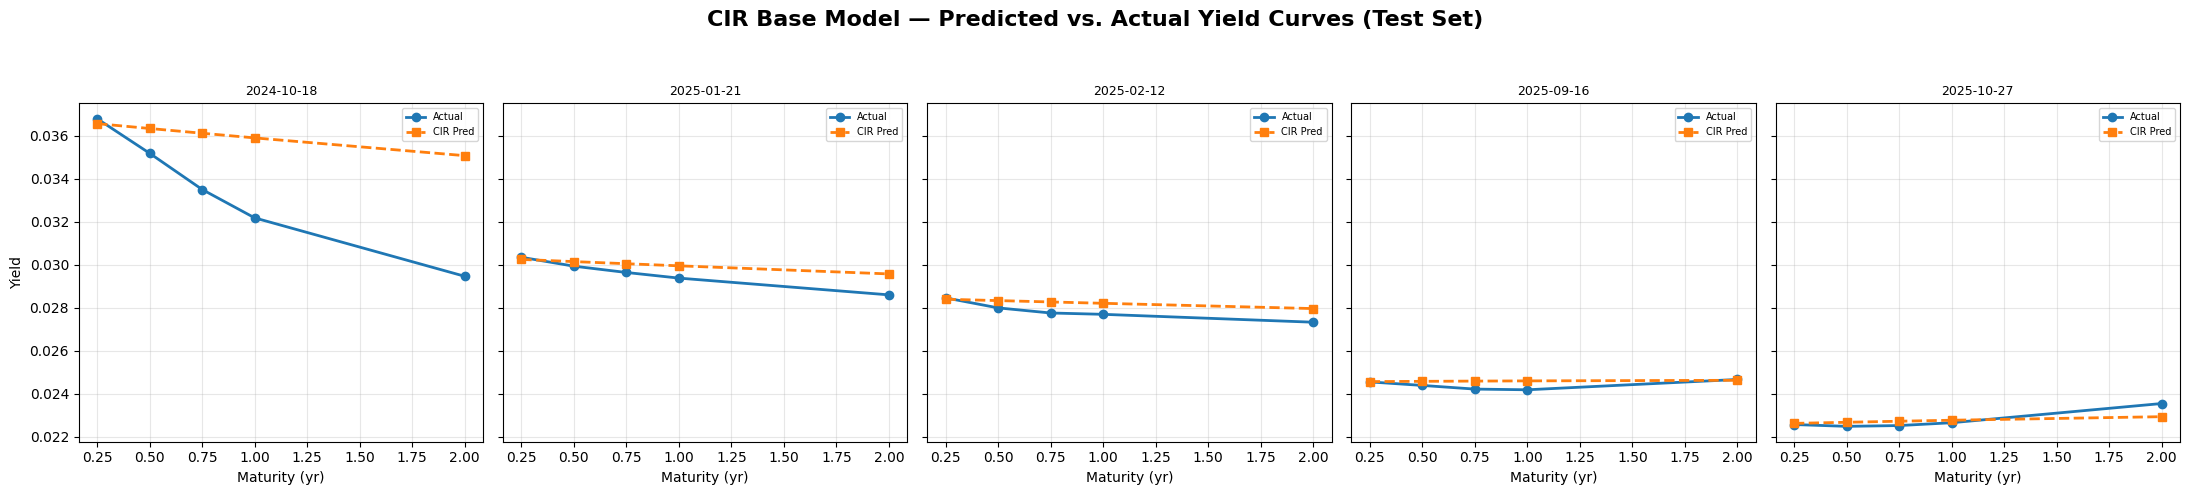

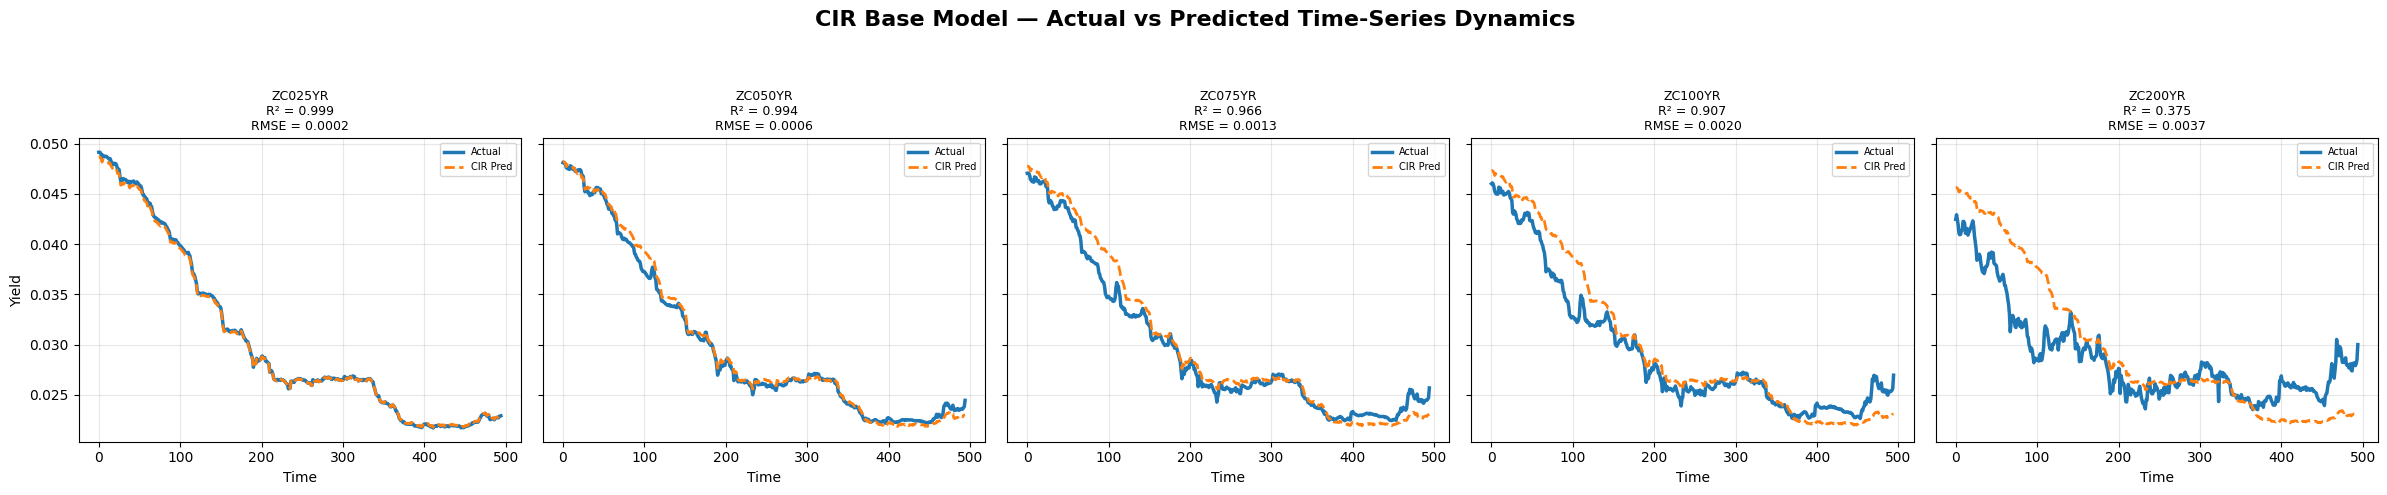

In [ ]:
# =========================================================
# TEST SHORT RATE
# =========================================================

test_r = df_test[" ZC025YR"].values

# =========================================================
# EXCLUDED MATURITIES
# =========================================================

excluded = {
    " ZC500YR",
    " ZC1000YR",
    " ZC2000YR",
    " ZC3000YR"
}

# =========================================================
# VALID MATURITIES
# =========================================================

valid_maturities = [
    m for m in maturities.keys()
    if m not in excluded
]

# =========================================================
# SORT MATURITIES
# =========================================================

valid_maturities = sorted(
    valid_maturities,
    key=lambda x: maturities[x]
)

# =========================================================
# PREDICTIONS
# =========================================================

predictions = {}

for maturity_name in valid_maturities:

    tau = maturities[maturity_name]

    predicted_yields = np.array([

        cir_yield(
            kappa_hat,
            theta_hat,
            sigma_hat,
            r,
            tau
        )

        for r in test_r
    ])

    predictions[maturity_name] = predicted_yields

# =========================================================
# EVALUATION
# =========================================================

print("========================================")
print("OUT-OF-SAMPLE PERFORMANCE")
print("========================================")

all_actual = []
all_predicted = []

for maturity_name in valid_maturities:

    actual = df_test[maturity_name].values

    predicted = predictions[maturity_name]

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    r2 = r2_score(actual, predicted)

    print(f"\n{maturity_name}")

    print(f"RMSE = {rmse:.6f}")
    print(f"R2   = {r2:.6f}")

    all_actual.extend(actual)
    all_predicted.extend(predicted)

# =========================================================
# GLOBAL METRICS
# =========================================================

overall_r2 = r2_score(
    all_actual,
    all_predicted
)

overall_rmse = np.sqrt(
    mean_squared_error(
        all_actual,
        all_predicted
    )
)

print("\n========================================")
print("OVERALL PERFORMANCE")
print("========================================")

print(f"Overall RMSE = {overall_rmse:.6f}")
print(f"Overall R2   = {overall_r2:.6f}")

# =========================================================
# MULTI-DAY YIELD CURVE PLOTS
# =========================================================

random_days = sorted(
    random.sample(
        range(len(df_test)),
        5
    )
)

fig, axes = plt.subplots(
    1,
    5,
    figsize=(22,5),
    sharey=True
)

fig.suptitle(
    "CIR Base Model — Predicted vs. Actual Yield Curves (Test Set)",
    fontsize=16,
    fontweight='bold'
)

for idx, sample_index in enumerate(random_days):

    ax = axes[idx]

    market_curve = []
    pred_curve = []
    x_axis = []

    sample_r = test_r[sample_index]

    for maturity_name in valid_maturities:

        tau = maturities[maturity_name]

        x_axis.append(tau)

        # actual market curve
        market_curve.append(
            df_test.iloc[sample_index][maturity_name]
        )

        # predicted CIR curve
        pred_curve.append(
            cir_yield(
                kappa_hat,
                theta_hat,
                sigma_hat,
                sample_r,
                tau
            )
        )

    # =====================================================
    # PLOT
    # =====================================================

    ax.plot(
        x_axis,
        market_curve,
        marker='o',
        linewidth=2,
        label='Actual'
    )

    ax.plot(
        x_axis,
        pred_curve,
        marker='s',
        linestyle='--',
        linewidth=2,
        label='CIR Pred'
    )

    # =====================================================
    # STYLING
    # =====================================================

    date_label = str(
        df_test.iloc[sample_index]["Date"]
    )

    ax.set_title(
        date_label,
        fontsize=9
    )

    ax.set_xlabel("Maturity (yr)")

    ax.grid(True, alpha=0.3)

    if idx == 0:
        ax.set_ylabel("Yield")

    ax.legend(fontsize=7)

# =========================================================
# FINAL LAYOUT
# =========================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

plt.show()

# =========================================================
#  TIME-SERIES ANALYSIS
# =========================================================

fig, axes = plt.subplots(
    1,
    len(valid_maturities),
    figsize=(24,5),
    sharey=True
)

fig.suptitle(
    "CIR Base Model — Actual vs Predicted Time-Series Dynamics",
    fontsize=16,
    fontweight='bold'
)

# =========================================================
# LOOP OVER MATURITIES
# =========================================================

for idx, maturity_name in enumerate(valid_maturities):

    ax = axes[idx]

    actual = df_test[maturity_name].values

    predicted = predictions[maturity_name]

    # =====================================================
    # METRICS
    # =====================================================

    r2 = r2_score(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    # =====================================================
    # PLOT
    # =====================================================

    ax.plot(
        actual,
        linewidth=2.5,
        label='Actual'
    )

    ax.plot(
        predicted,
        linewidth=2,
        linestyle='--',
        label='CIR Pred'
    )

    # =====================================================
    # STYLING
    # =====================================================

    ax.set_title(
        f"{maturity_name.strip()}\n"
        f"R² = {r2:.3f}\n"
        f"RMSE = {rmse:.4f}",
        fontsize=9
    )

    ax.set_xlabel("Time")

    if idx == 0:
        ax.set_ylabel("Yield")

    ax.grid(True, alpha=0.3)

    ax.legend(fontsize=7)

# =========================================================
# FINAL LAYOUT
# =========================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.92]
)

plt.show()

# CIR++ Extension

The base CIR model showed strong time-series performance but struggled to fully reproduce the shape of the market yield curve, especially for longer maturities.

To improve the cross-sectional fit of the term structure, a CIR++ extension was implemented.

The CIR++ framework augments the base CIR model with a deterministic shift function:

$$
y^{CIR++}(t,\tau)
=

y^{CIR}(t,\tau)
+
\phi(\tau)
$$

where:

* (y^{CIR}(t,\tau)) is the original CIR yield,
* (\phi(\tau)) is a maturity-dependent deterministic correction term.

---

# Shift Function Estimation

For each maturity, the average residual between:

* market yields,
* and CIR-implied yields,

was computed:

$$
\phi(\tau)
=

\mathbb{E}
\left[
y^{market}
-

y^{CIR}
\right]
$$

This deterministic adjustment allows the model to better align with the observed market term structure while preserving the stochastic dynamics of the original CIR process.

---

# CIR++ Yield Construction

The CIR++ yield function was implemented as:

```python id="2zxm5u"
return base_yield + shift
```

Thus, the CIR++ model preserves:

* mean reversion,
* stochastic volatility,
* positivity structure,

while correcting systematic curve-fitting errors.

---

# Out-of-Sample Prediction

Similar to the base CIR framework, the CIR++ model only used the 3M yield from the test dataset as the short-rate input:

```python id="61a8xp"
test_r = df_test[" ZC025YR"].values
```

The calibrated CIR parameters together with the deterministic shift function were then used to reconstruct the entire yield curve.

---

# Performance Evaluation

The CIR++ predictions were evaluated using:

* RMSE,
* (R^2),
* global performance metrics.

The results demonstrated that CIR++ significantly improved the cross-sectional fit of the yield curve compared to the base CIR model.

This improvement occurred because the deterministic shift function compensated for structural biases in the one-factor CIR framework.

---

# Yield Curve Visualization

Five random days from the test dataset were selected to visually compare:

* actual market curves,
* base CIR curves,
* CIR++ curves.

The CIR++ curves generally tracked the market term structure more accurately, especially at medium and longer maturities.

---

# Time-Series Dynamics

Time-series plots were also generated for each maturity to compare:

* actual yields,
* CIR predictions,
* CIR++ predictions.

The maturity-wise (R^2) values showed that CIR++ consistently improved predictive accuracy while preserving the dynamic behavior learned by the base CIR model.

---

# Interpretation

The CIR++ extension improved the flexibility of the model without abandoning the theoretical foundation of the CIR stochastic process.

The deterministic shift function effectively corrected:

* long-end flattening,
* curve-shape bias,
* systematic underestimation of yields.

However, CIR++ still inherits several limitations from the original CIR framework because the underlying dynamics are still driven by a single stochastic factor.

Nevertheless, the CIR++ model provided a significantly better empirical fit and more realistic yield-curve reconstruction for practical fixed-income modelling.


CIR++ PERFORMANCE

 ZC025YR
RMSE = 0.000321
R2   = 0.998571

 ZC050YR
RMSE = 0.001173
R2   = 0.977856

 ZC075YR
RMSE = 0.002207
R2   = 0.906602

 ZC100YR
RMSE = 0.003149
R2   = 0.771012

 ZC200YR
RMSE = 0.003733
R2   = 0.362955

GLOBAL CIR++ PERFORMANCE
Overall RMSE = 0.002458
Overall R2   = 0.880789


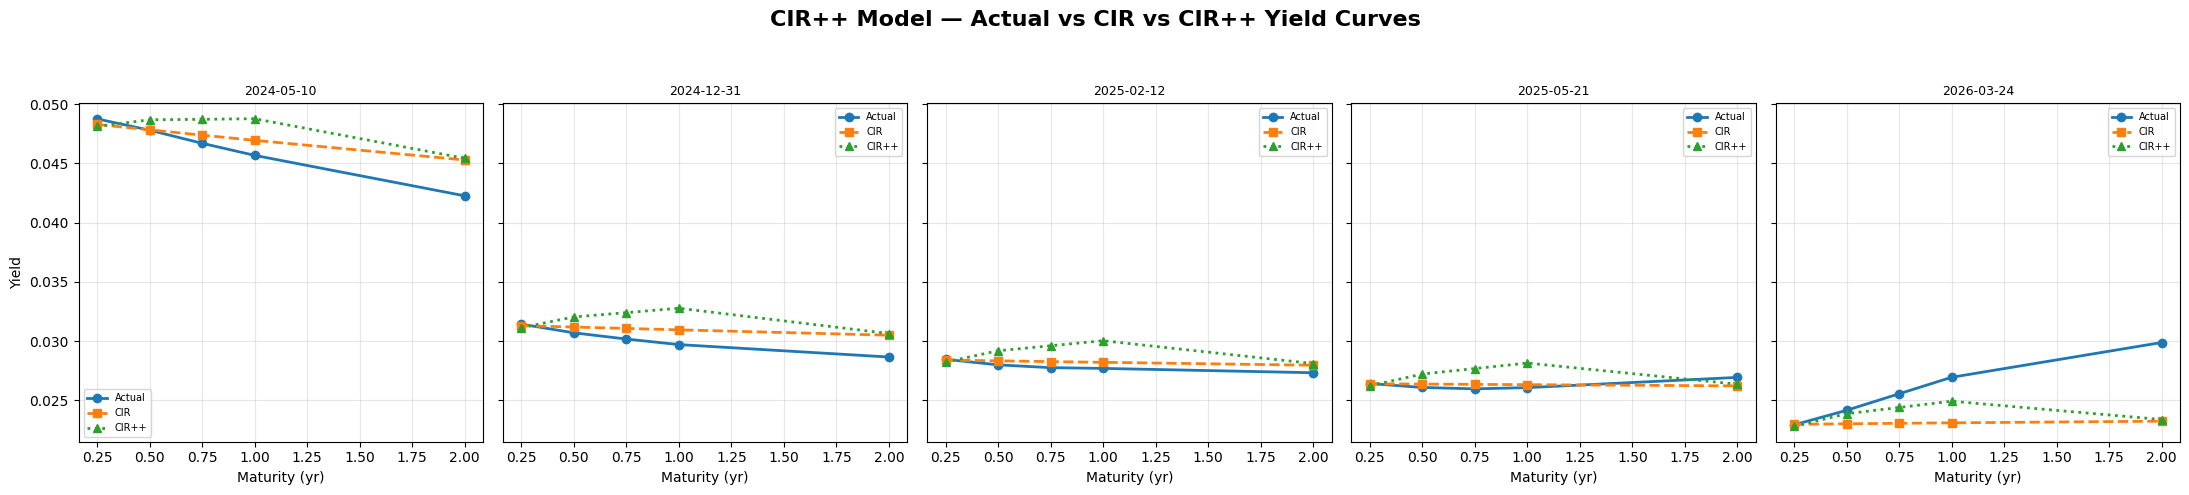

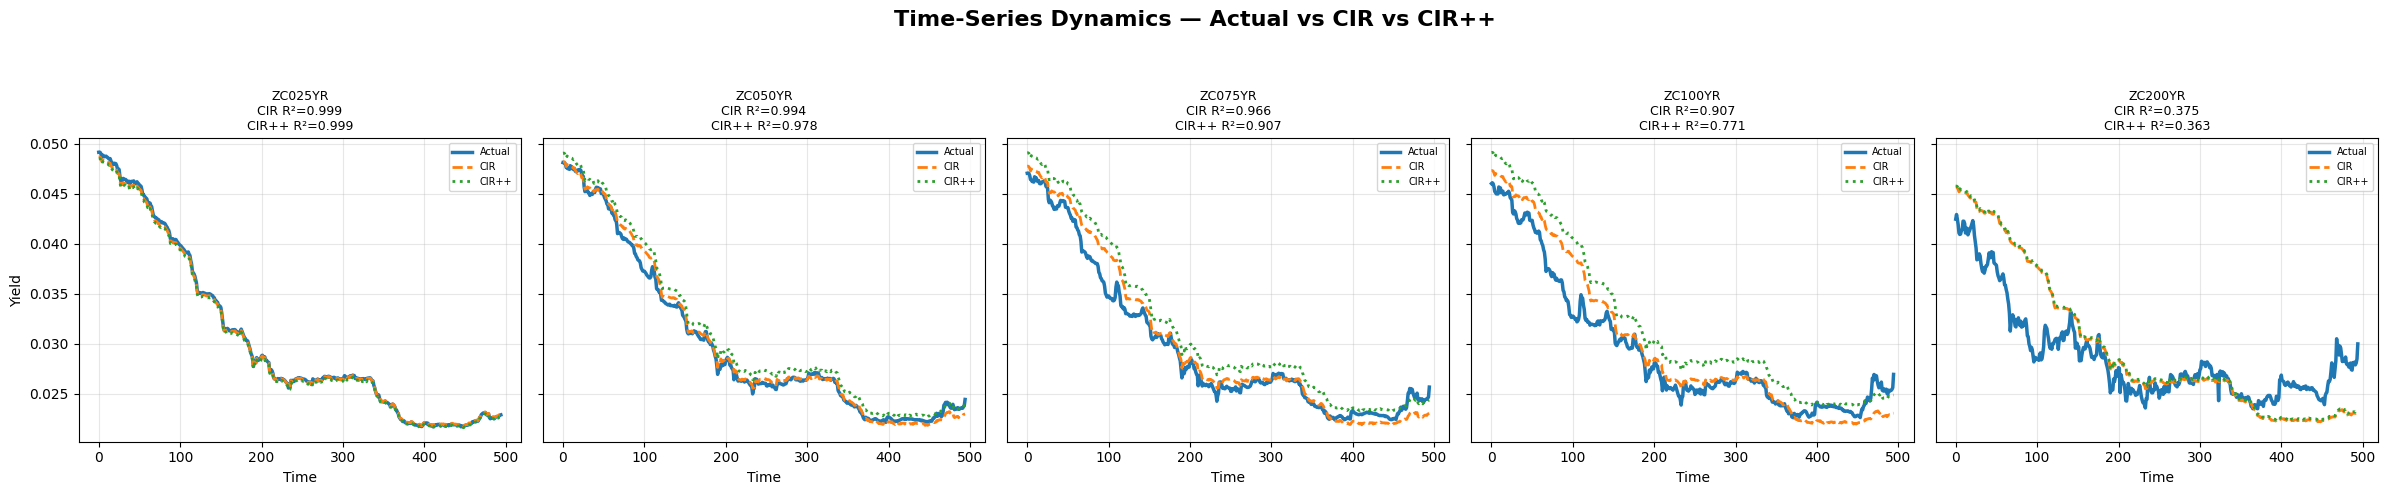

In [ ]:
# =========================================================
# CIR++ IMPLEMENTATION + BEAUTIFUL VISUALIZATION
# =========================================================
# =========================================================
# STEP 1: ESTIMATE SHIFT FUNCTION
# =========================================================

phi = {}

for maturity_name, tau in maturities.items():

    market_yields = df_train[maturity_name].values

    cir_model_yields = np.array([

        cir_yield(
            kappa_hat,
            theta_hat,
            sigma_hat,
            r,
            tau
        )

        for r in r_t
    ])

    # deterministic residual correction
    shift = np.mean(
        market_yields - cir_model_yields
    )

    phi[maturity_name] = shift

# =========================================================
# STEP 2: CIR++ YIELD FUNCTION
# =========================================================

def cirpp_yield(
    kappa,
    theta,
    sigma,
    r,
    tau,
    shift
):

    base_yield = cir_yield(
        kappa,
        theta,
        sigma,
        r,
        tau
    )

    return base_yield + shift

# =========================================================
# STEP 3: TEST SHORT RATE
# =========================================================

test_r = df_test[" ZC025YR"].values

# =========================================================
# SORT MATURITIES
# =========================================================
evaluation_maturities = [

    " ZC025YR",   # 3M
    " ZC050YR",   # 6M
    " ZC075YR",   # 9M
    " ZC100YR",   # 1Y
    " ZC200YR"    # 2Y

]
sorted_maturities = sorted(
    evaluation_maturities,
    key=lambda x: maturities[x]
)

# =========================================================
# STEP 4: PREDICTIONS
# =========================================================

cirpp_predictions = {}

for maturity_name in sorted_maturities:

    tau = maturities[maturity_name]

    preds = np.array([

        cirpp_yield(
            kappa_hat,
            theta_hat,
            sigma_hat,
            r,
            tau,
            phi[maturity_name]
        )

        for r in test_r
    ])

    cirpp_predictions[maturity_name] = preds

# =========================================================
# STEP 5: EVALUATION
# =========================================================

print("================================")
print("CIR++ PERFORMANCE")
print("================================")

all_actual = []
all_pred = []

for maturity_name in sorted_maturities:

    actual = df_test[maturity_name].values

    pred = cirpp_predictions[maturity_name]

    rmse = np.sqrt(
        mean_squared_error(actual, pred)
    )

    r2 = r2_score(actual, pred)

    print(f"\n{maturity_name}")

    print(f"RMSE = {rmse:.6f}")
    print(f"R2   = {r2:.6f}")

    all_actual.extend(actual)
    all_pred.extend(pred)

# =========================================================
# GLOBAL PERFORMANCE
# =========================================================

overall_r2 = r2_score(
    all_actual,
    all_pred
)

overall_rmse = np.sqrt(
    mean_squared_error(
        all_actual,
        all_pred
    )
)

print("\n================================")
print("GLOBAL CIR++ PERFORMANCE")
print("================================")

print(f"Overall RMSE = {overall_rmse:.6f}")
print(f"Overall R2   = {overall_r2:.6f}")

# =========================================================
#  MULTI-DAY YIELD CURVE COMPARISON
# =========================================================

random_days = sorted(
    random.sample(
        range(len(df_test)),
        5
    )
)

fig, axes = plt.subplots(
    1,
    5,
    figsize=(22,5),
    sharey=True
)

fig.suptitle(
    "CIR++ Model — Actual vs CIR vs CIR++ Yield Curves",
    fontsize=16,
    fontweight='bold'
)

for idx, sample_index in enumerate(random_days):

    ax = axes[idx]

    market_curve = []
    cir_curve = []
    cirpp_curve = []
    x_axis = []

    sample_r = test_r[sample_index]

    for maturity_name in sorted_maturities:

        tau = maturities[maturity_name]

        x_axis.append(tau)

        # actual market curve
        market_curve.append(
            df_test.iloc[sample_index][maturity_name]
        )

        # base CIR
        cir_curve.append(
            cir_yield(
                kappa_hat,
                theta_hat,
                sigma_hat,
                sample_r,
                tau
            )
        )

        # CIR++
        cirpp_curve.append(
            cirpp_yield(
                kappa_hat,
                theta_hat,
                sigma_hat,
                sample_r,
                tau,
                phi[maturity_name]
            )
        )

    # =====================================================
    # PLOT
    # =====================================================

    ax.plot(
        x_axis,
        market_curve,
        marker='o',
        linewidth=2,
        label='Actual'
    )

    ax.plot(
        x_axis,
        cir_curve,
        marker='s',
        linestyle='--',
        linewidth=2,
        label='CIR'
    )

    ax.plot(
        x_axis,
        cirpp_curve,
        marker='^',
        linestyle=':',
        linewidth=2,
        label='CIR++'
    )

    # =====================================================
    # STYLING
    # =====================================================

    date_label = str(
        df_test.iloc[sample_index]["Date"]
    )

    ax.set_title(
        date_label,
        fontsize=9
    )

    ax.set_xlabel("Maturity (yr)")

    ax.grid(True, alpha=0.3)

    if idx == 0:
        ax.set_ylabel("Yield")

    ax.legend(fontsize=7)

# =========================================================
# FINAL LAYOUT
# =========================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

plt.show()

# =========================================================
#  TIME-SERIES ANALYSIS
# =========================================================

fig, axes = plt.subplots(
    1,
    len(sorted_maturities),
    figsize=(24,5),
    sharey=True
)

fig.suptitle(
    "Time-Series Dynamics — Actual vs CIR vs CIR++",
    fontsize=16,
    fontweight='bold'
)

# =========================================================
# LOOP OVER MATURITIES
# =========================================================

for idx, maturity_name in enumerate(sorted_maturities):

    ax = axes[idx]

    actual = df_test[maturity_name].values

    cir_pred = np.array([
        cir_yield(
            kappa_hat,
            theta_hat,
            sigma_hat,
            r,
            maturities[maturity_name]
        )
        for r in test_r
    ])

    cirpp_pred = cirpp_predictions[maturity_name]

    # =====================================================
    # METRICS
    # =====================================================

    cir_r2 = r2_score(
        actual,
        cir_pred
    )

    cirpp_r2 = r2_score(
        actual,
        cirpp_pred
    )

    # =====================================================
    # PLOT
    # =====================================================

    ax.plot(
        actual,
        linewidth=2.5,
        label='Actual'
    )

    ax.plot(
        cir_pred,
        linewidth=2,
        linestyle='--',
        label='CIR'
    )

    ax.plot(
        cirpp_pred,
        linewidth=2,
        linestyle=':',
        label='CIR++'
    )

    # =====================================================
    # STYLING
    # =====================================================

    ax.set_title(
        f"{maturity_name.strip()}\n"
        f"CIR R²={cir_r2:.3f}\n"
        f"CIR++ R²={cirpp_r2:.3f}",
        fontsize=9
    )

    ax.set_xlabel("Time")

    if idx == 0:
        ax.set_ylabel("Yield")

    ax.grid(True, alpha=0.3)

    ax.legend(fontsize=7)

# =========================================================
# FINAL LAYOUT
# =========================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.92]
)

plt.show()